# **LAB SLOT 09 - LAB VECTOR HÓA CHUỖI KÝ TỰ**
**Sinh viên:** Nguyễn Văn Anh Duy  
**MSSV:** SE181823  
**Lớp:** AI1803

---
**Yêu cầu:** Thực hiện lại cách code giống trên slide 3.5 hướng dẫn, nộp link google colab notebook



---
## **Bước 1: Import thư viện và thiết lập Hyperparameters**

Các tham số cấu hình cho mô hình phân loại văn bản (dựa trên slide 3.5):

In [1]:
import json
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tham số cấu hình (Hyperparameters)
vocab_size = 10000       # Số lượng từ vựng tối đa
embedding_dim = 16       # Kích thước vector nhúng
max_length = 100         # Độ dài tối đa của câu (headlines)
trunc_type = 'post'      # Cắt bớt phần sau nếu quá dài
padding_type = 'post'    # Thêm padding vào phía sau
oov_tok = "<OOV>"        # Token cho các từ không có trong từ điển
training_size = 20000    # Số lượng dữ liệu dùng để train

print("Import thư viện thành công!")
print(f"TensorFlow version: {tf.__version__}")

Import thư viện thành công!
TensorFlow version: 2.20.0


---
## **Bước 2: Tải và Xử lý dữ liệu**

Dataset Sarcasm Detection có cấu trúc JSON với các trường:
- `is_sarcastic`: Nhãn (0 = không sarcastic, 1 = sarcastic)
- `headline`: Tiêu đề tin tức
- `article_link`: Đường dẫn đến bài báo gốc

```json
{
  "is_sarcastic": 1,
  "headline": "thirtysomething scientists unveil doomsday clock of hair loss",
  "article_link": "https://www.theonion.com/..."
}
```

In [2]:
# Đọc dữ liệu từ file JSON
# Thử cả hai tên file phổ biến
import os

file_names = ['Sarcasm_Headlines_Dataset.json', 'Sarcasm_Headlines_Dataset_v2.json', 'sarcasm.json']
json_file = None

for fname in file_names:
    if os.path.exists(fname):
        json_file = fname
        break

if json_file is None:
    print("[ERROR] Không tìm thấy file dữ liệu!")
    print("Vui lòng tải file từ Kaggle:")
    print("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")
    print("\nHoặc sử dụng code sau để upload file (trên Google Colab):")
    print("from google.colab import files")
    print("uploaded = files.upload()")
    raise FileNotFoundError("Dataset file not found. Please upload the Sarcasm dataset JSON file.")

# Đọc file JSON (hỗ trợ cả JSON array và JSON Lines format)
datastore = []
with open(json_file, 'r') as f:
    # Thử đọc như JSON array trước
    try:
        f.seek(0)
        datastore = json.load(f)
    except json.JSONDecodeError:
        # Nếu lỗi, đọc như JSON Lines (mỗi dòng là một JSON object)
        f.seek(0)
        for line in f:
            datastore.append(json.loads(line))

print(f"[SUCCESS] Đã tải file: {json_file}")
print(f"Tổng số dữ liệu: {len(datastore)} headlines")

# Trích xuất dữ liệu từ JSON
sentences = []
labels = []

for item in datastore:
    sentences.append(item['headline'])      # Lấy nội dung headline
    labels.append(item['is_sarcastic'])     # Lấy nhãn (0: không sarcastic, 1: sarcastic)

# Chia dữ liệu thành tập Train và Test
training_sentences = sentences[0:training_size]
testing_sentences = sentences[training_size:]
training_labels = labels[0:training_size]
testing_labels = labels[training_size:]

print("\n=== PHÂN CHIA DỮ LIỆU ===")
print(f"Training set: {len(training_sentences)} samples")
print(f"Testing set: {len(testing_sentences)} samples")
print("\n=== VÍ DỤ DỮ LIỆU ===")
print(f"Headline: {training_sentences[0]}")
print(f"Label (is_sarcastic): {training_labels[0]}")

[SUCCESS] Đã tải file: Sarcasm_Headlines_Dataset.json
Tổng số dữ liệu: 26709 headlines

=== PHÂN CHIA DỮ LIỆU ===
Training set: 20000 samples
Testing set: 6709 samples

=== VÍ DỤ DỮ LIỆU ===
Headline: former versace store clerk sues over secret 'black code' for minority shoppers
Label (is_sarcastic): 0


---
## **Bước 3: Tokenization (Mã hóa từ)**

**Tokenization** là quá trình chuyển đổi văn bản thành các token (từ) và gán cho mỗi từ một chỉ số duy nhất.

- `Tokenizer` học từ vựng từ tập dữ liệu huấn luyện
- Tạo một từ điển (word index) ánh xạ từ → số
- Các từ không có trong từ điển sẽ được thay bằng token `<OOV>` (Out Of Vocabulary)

In [3]:
# Khởi tạo Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)

# Học từ vựng từ dữ liệu train
tokenizer.fit_on_texts(training_sentences)

# Lấy chỉ mục từ (Word Index)
word_index = tokenizer.word_index

print("[SUCCESS] Tokenization hoàn tất!")
print(f"Số lượng từ vựng duy nhất: {len(word_index)}")
print(f"Số lượng từ vựng sử dụng: {vocab_size}")
print("\nTop 10 từ phổ biến nhất:")
for word, index in list(word_index.items())[:10]:
    print(f"  {index}: {word}")

[SUCCESS] Tokenization hoàn tất!
Số lượng từ vựng duy nhất: 25637
Số lượng từ vựng sử dụng: 10000

Top 10 từ phổ biến nhất:
  1: <OOV>
  2: to
  3: of
  4: the
  5: in
  6: for
  7: a
  8: on
  9: and
  10: with


---
## **Bước 4: Tạo Sequences và Padding**

**Sequences:** Chuyển đổi các câu văn thành chuỗi số nguyên dựa trên word index.

**Padding:** Làm đều độ dài của các câu:
- Nếu câu ngắn hơn `max_length` → thêm số 0 vào cuối (`padding_type='post'`)
- Nếu câu dài hơn `max_length` → cắt bớt phần cuối (`trunc_type='post'`)

In [4]:
# Chuyển đổi câu train thành chuỗi số
training_sequences = tokenizer.texts_to_sequences(training_sentences)

# Padding cho câu train
training_padded = pad_sequences(training_sequences, maxlen=max_length, 
                                padding=padding_type, truncating=trunc_type)

# Chuyển đổi và Padding cho câu test
testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, 
                               padding=padding_type, truncating=trunc_type)

print("[SUCCESS] Sequences và Padding hoàn tất!")
print("\n=== SHAPE CỦA DỮ LIỆU ===")
print(f"Training padded: {training_padded.shape}")
print(f"Testing padded: {testing_padded.shape}")
print("\n=== VÍ DỤ CÂU BAN ĐẦU ===")
print(f"Text: {training_sentences[0]}")
print(f"Sequence: {training_sequences[0]}")
print(f"Padded: {training_padded[0]}")

[SUCCESS] Sequences và Padding hoàn tất!

=== SHAPE CỦA DỮ LIỆU ===
Training padded: (20000, 100)
Testing padded: (6709, 100)

=== VÍ DỤ CÂU BAN ĐẦU ===
Text: former versace store clerk sues over secret 'black code' for minority shoppers
Sequence: [328, 1, 799, 3405, 2404, 47, 389, 2214, 1, 6, 2614, 8863]
Padded: [ 328    1  799 3405 2404   47  389 2214    1    6 2614 8863    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


---
## **Bước 5: Chuyển đổi Labels sang NumPy Array**

TensorFlow yêu cầu training labels phải là NumPy arrays để đưa vào mô hình.

In [5]:
# Chuyển đổi list labels thành numpy array
training_labels = np.array(training_labels)
testing_labels = np.array(testing_labels)

print("[SUCCESS] Chuyển đổi labels thành NumPy array!")
print(f"Training labels shape: {training_labels.shape}")
print(f"Testing labels shape: {testing_labels.shape}")
print("\n=== PHÂN BỐ LABELS TRONG TRAINING SET ===")
unique, counts = np.unique(training_labels, return_counts=True)
for label, count in zip(unique, counts):
    label_name = "Not Sarcastic" if label == 0 else "Sarcastic"
    print(f"{label_name} ({label}): {count} samples ({count/len(training_labels)*100:.1f}%)")

[SUCCESS] Chuyển đổi labels thành NumPy array!
Training labels shape: (20000,)
Testing labels shape: (6709,)

=== PHÂN BỐ LABELS TRONG TRAINING SET ===
Not Sarcastic (0): 11206 samples (56.0%)
Sarcastic (1): 8794 samples (44.0%)


---
## **Bước 6: Xây dựng Mô hình Neural Network**

Kiến trúc mô hình (theo slide 3.5):
1. **Embedding Layer**: Chuyển từ (số nguyên) thành vector `embedding_dim` chiều
   - Giúp biểu diễn từ trong không gian nhiều chiều
   - Các từ có nghĩa tương tự sẽ có vector gần nhau
2. **Flatten Layer**: Duỗi mảng 2D thành 1D
3. **Dense Layer (Hidden)**: 6 neurons với ReLU activation
4. **Dense Layer (Output)**: 1 neuron với Sigmoid activation (phân loại nhị phân 0/1)

In [6]:
model = tf.keras.Sequential([
    # Lớp Embedding: Tạo vector biểu diễn từ
    # Input: vocab_size, Output: embedding_dim
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    
    # Lớp Flatten: Duỗi mảng 2D thành 1D
    tf.keras.layers.Flatten(),
    
    # Lớp Dense ẩn: 6 nơ-ron, hàm kích hoạt ReLU
    tf.keras.layers.Dense(6, activation='relu'),
    
    # Lớp Output: 1 nơ-ron, hàm kích hoạt Sigmoid (phân loại nhị phân 0/1)
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Biên dịch mô hình
model.compile(
    loss='binary_crossentropy',  # Hàm mất mát cho bài toán phân loại nhị phân
    optimizer='adam',             # Thuật toán tối ưu Adam
    metrics=['accuracy']          # Đo lường độ chính xác
)

# Hiển thị cấu trúc mô hình
print("[SUCCESS] Xây dựng mô hình thành công!\n")
model.summary()

[SUCCESS] Xây dựng mô hình thành công!



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## **Bước 7: Huấn luyện Mô hình**

Huấn luyện mô hình với dữ liệu training và đánh giá trên dữ liệu testing.

  - Chỉ lưu weights (save_weights_only=False) để có thể tải lại toàn bộ mô hình

**Kỹ thuật sử dụng:**  - Lưu khi validation loss giảm

- **Early Stopping**: Dừng training sớm khi validation loss không cải thiện trong 3 epochs liên tiếp- **Model Checkpoint**: Tự động lưu mô hình tốt nhất trong quá trình training

  - Giúp ngăn overfitting

  - Tiết kiệm thời gian training  - Khôi phục weights tốt nhất (restore_best_weights=True)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Thiết lập callbacks
early_stop = EarlyStopping(
    monitor='val_loss',           # Theo dõi validation loss
    patience=3,                   # Dừng nếu không cải thiện sau 3 epochs
    restore_best_weights=True,    # Khôi phục weights tốt nhất
    verbose=1                     # Hiển thị thông báo khi dừng
)

checkpoint = ModelCheckpoint(
    'best_sarcasm_model.keras',   # Tên file lưu mô hình
    monitor='val_loss',           # Theo dõi validation loss
    save_best_only=True,          # Chỉ lưu khi có cải thiện
    mode='min',                   # Lưu khi val_loss nhỏ nhất
    verbose=1                     # Hiển thị thông báo khi lưu
)

num_epochs = 30  # Tăng số epochs vì có early stopping

print("=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ===\n")
print("Sử dụng Early Stopping (patience=3) và Model Checkpoint")
print(f"Số epochs tối đa: {num_epochs}\n")

history = model.fit(
    training_padded, 
    training_labels, 
    epochs=num_epochs, 
    validation_data=(testing_padded, testing_labels),
    callbacks=[early_stop, checkpoint],  # Thêm callbacks
    verbose=1
)

print("\n[SUCCESS] Huấn luyện hoàn tất!")
print(f"Tổng số epochs đã chạy: {len(history.history['loss'])}")
print(f"Mô hình tốt nhất đã được lưu tại: best_sarcasm_model.keras")

=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ===

Sử dụng Early Stopping (patience=3) và Model Checkpoint
Số epochs tối đa: 30

Epoch 1/30
607/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5980 - loss: 0.6505
Epoch 1: val_loss improved from None to 0.36035, saving model to best_sarcasm_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7007 - loss: 0.5481 - val_accuracy: 0.8468 - val_loss: 0.3604
Epoch 2/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.2904
Epoch 2: val_loss improved from 0.36035 to 0.32480, saving model to best_sarcasm_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8853 - loss: 0.2765 - val_accuracy: 0.8563 - val_loss: 0.3248
Epoch 3/30
608/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9279 - loss: 0.1969
Epoch 3: val_loss did not improve from 0.32480
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9282 - loss: 0.1891 - val_accuracy: 0.8603 - val_loss: 0.3286
Epoch 4/30
604/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

---
## **Bước 8: Đánh giá và Trực quan hóa Kết quả**

Visualize quá trình training để kiểm tra:
- **Accuracy**: Độ chính xác trên tập train và validation
- **Loss**: Hàm mất mát trên tập train và validation
- Kiểm tra **overfitting** (nếu validation accuracy giảm trong khi training accuracy tăng)

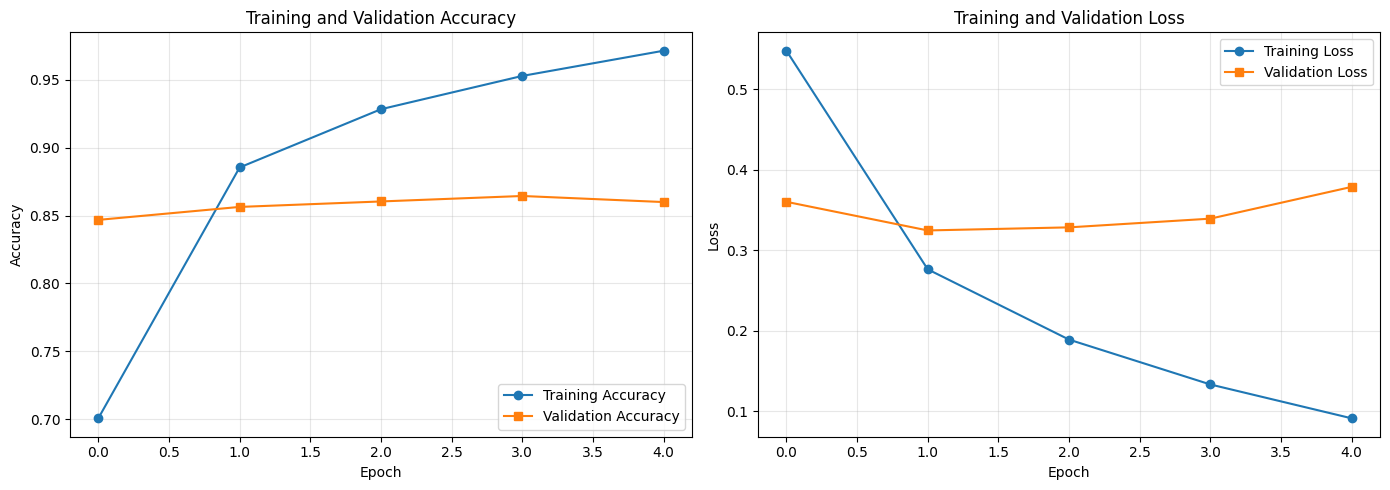


=== KẾT QUẢ CUỐI CÙNG ===
Training Accuracy: 0.9712 (97.12%)
Validation Accuracy: 0.8599 (85.99%)
Training Loss: 0.0913
Validation Loss: 0.3789


In [9]:
import matplotlib.pyplot as plt

# Trích xuất dữ liệu từ history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Sử dụng số epochs thực tế đã chạy (quan trọng khi có Early Stopping)
epochs_range = range(len(history.history['loss']))

# Vẽ biểu đồ
plt.figure(figsize=(14, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In kết quả cuối cùng
print("\n=== KẾT QUẢ CUỐI CÙNG ===")
print(f"Training Accuracy: {acc[-1]:.4f} ({acc[-1]*100:.2f}%)")
print(f"Validation Accuracy: {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)")
print(f"Training Loss: {loss[-1]:.4f}")
print(f"Validation Loss: {val_loss[-1]:.4f}")

---
## **Bước 9: Kiểm thử với Dữ liệu Mới**

Test mô hình với các headline tự tạo để xem khả năng dự đoán sarcasm.

In [10]:
# Các câu test mới
test_sentences = [
    "Local man breaks world record for most procrastination in single day",
    "Scientists discover cure for cancer",
    "Area woman wins lottery, still shops at discount store",
    "President announces new economic policy to boost growth",
    "Man accidentally becomes millionaire by following terrible investment advice"
]

# Chuyển đổi thành sequences và padding
test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, 
                           padding=padding_type, truncating=trunc_type)

# Dự đoán
predictions = model.predict(test_padded)

# Hiển thị kết quả
print("=== DỰ ĐOÁN TRÊN DỮ LIỆU MỚI ===\n")
for i, sentence in enumerate(test_sentences):
    score = predictions[i][0]
    label = "SARCASTIC" if score > 0.5 else "NOT SARCASTIC"
    print(f"{i+1}. Headline: \"{sentence}\"")
    print(f"   Prediction: {label} (Score: {score:.4f})")
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
=== DỰ ĐOÁN TRÊN DỮ LIỆU MỚI ===

1. Headline: "Local man breaks world record for most procrastination in single day"
   Prediction: SARCASTIC (Score: 0.9870)

2. Headline: "Scientists discover cure for cancer"
   Prediction: SARCASTIC (Score: 0.9201)

3. Headline: "Area woman wins lottery, still shops at discount store"
   Prediction: SARCASTIC (Score: 0.9988)

4. Headline: "President announces new economic policy to boost growth"
   Prediction: SARCASTIC (Score: 0.5284)

5. Headline: "Man accidentally becomes millionaire by following terrible investment advice"
   Prediction: SARCASTIC (Score: 0.9712)



---
## **Bước 10: Trực quan hóa Embedding Vectors (Tùy chọn)**

Xem vector embedding của một số từ để hiểu cách mô hình biểu diễn từ trong không gian nhiều chiều.

In [11]:
# Lấy embedding weights từ lớp đầu tiên
embedding_layer = model.layers[0]
embedding_weights = embedding_layer.get_weights()[0]

print(f"Embedding Matrix Shape: {embedding_weights.shape}")
print(f"Số từ vựng: {embedding_weights.shape[0]}")
print(f"Chiều vector: {embedding_weights.shape[1]}")

# Hiển thị embedding của một số từ cụ thể
sample_words = ['trump', 'obama', 'funny', 'sad', 'news', 'breaking']
print("\n=== EMBEDDING VECTORS CỦA MỘT SỐ TỪ ===\n")

for word in sample_words:
    if word in word_index:
        word_id = word_index[word]
        if word_id < vocab_size:
            embedding_vector = embedding_weights[word_id]
            print(f"Từ: '{word}' (ID: {word_id})")
            print(f"Vector: {embedding_vector[:8]}... (showing first 8 dimensions)")
            print()
    else:
        print(f"Từ '{word}' không có trong từ điển\n")

Embedding Matrix Shape: (10000, 16)
Số từ vựng: 10000
Chiều vector: 16

=== EMBEDDING VECTORS CỦA MỘT SỐ TỪ ===

Từ: 'trump' (ID: 13)
Vector: [-0.16878214 -0.29486144  0.21998543  0.06156049  0.03437584 -0.13938732
  0.17283663  0.1445189 ]... (showing first 8 dimensions)

Từ: 'obama' (ID: 67)
Vector: [ 0.01886694 -0.02854472  0.03150658 -0.04548577 -0.02867354 -0.02605488
 -0.02424348 -0.0073557 ]... (showing first 8 dimensions)

Từ: 'funny' (ID: 2194)
Vector: [ 0.08323996  0.02770005 -0.12073895 -0.05613476 -0.05111066  0.07322804
 -0.12392801 -0.06991171]... (showing first 8 dimensions)

Từ: 'sad' (ID: 1074)
Vector: [ 0.09085622 -0.00700549 -0.05240372 -0.04138593 -0.047043    0.04071581
 -0.06899887 -0.02459342]... (showing first 8 dimensions)

Từ: 'news' (ID: 183)
Vector: [-0.04828397 -0.09932075 -0.00278268  0.04109218  0.06084359 -0.08060506
  0.04948235  0.03984977]... (showing first 8 dimensions)

Từ: 'breaking' (ID: 460)
Vector: [ 0.20537844  0.16457741 -0.11877412 -0.1573448

---
## **KẾT LUẬN**

Bài lab này đã minh họa quy trình hoàn chỉnh để xây dựng một mô hình phân loại văn bản sử dụng Neural Network với Embedding Layer. Thông qua việc thực hành với bộ dữ liệu **Sarcasm Detection**, chúng ta đã áp dụng các kỹ thuật xử lý ngôn ngữ tự nhiên (NLP) cơ bản để chuyển đổi văn bản thành dạng số mà máy tính có thể học được.

### Các kiến thức trọng tâm:

**1. Vector Hóa văn bản (Text Vectorization)**
- Quá trình chuyển đổi văn bản thành biểu diễn số là bước quan trọng trong NLP
- Tokenization giúp phân tách văn bản thành các đơn vị nhỏ hơn (tokens) và gán chỉ số duy nhất
- Padding đảm bảo tất cả input có cùng kích thước để đưa vào mạng nơ-ron

**2. Embedding Layer**
- Tạo ra không gian vector nhiều chiều để biểu diễn từ
- Các từ có nghĩa tương tự sẽ có vector gần nhau trong không gian này
- Là nền tảng cho các mô hình NLP hiện đại như BERT, GPT

**3. Kỹ thuật training hiệu quả**
- Early Stopping giúp ngăn overfitting và tiết kiệm thời gian
- Model Checkpoint đảm bảo không mất mô hình tốt nhất trong quá trình training
- Monitoring cả training và validation metrics giúp phát hiện vấn đề sớm

### Ứng dụng thực tế:

Mô hình phân loại Sarcasm Detection có thể được áp dụng trong:
- Phân tích sentiment trên mạng xã hội
- Lọc và phân loại tin tức tự động
- Hỗ trợ chatbot hiểu ngữ cảnh và sắc thái ngôn ngữ
- Nghiên cứu hành vi người dùng trực tuyến

### Hướng phát triển:

Để cải thiện mô hình hiện tại, có thể:
- Thử nghiệm các kiến trúc phức tạp hơn (LSTM, GRU, Transformer)
- Tăng kích thước embedding dimension và số lượng từ vựng
- Áp dụng transfer learning với pre-trained embeddings (Word2Vec, GloVe)
- Thêm các lớp Dropout để giảm overfitting
- Sử dụng data augmentation để tăng cường dữ liệu training